In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading:

In [2]:
# Read data
test_users = pd.read_csv('../data/raw/test_users.csv')

In [3]:
# Display the first 5 rows
test_users.head()

,UserID,City,State,Country,ZipCode,DegreeType,Major,GraduationDate,WorkHistoryCount,TotalYearsExperience,CurrentlyEmployed,MajorCategoryID
0,12924,Chicago,IL,US,60628,Bachelor's,NaN,2005-05-01 00:00:00,4,9.0,Yes,NaN
1,18947,Chicago,IL,US,60647,NaN,NaN,NaN,6,22.0,Yes,NaN
2,20976,Rolling Meadows,IL,US,60008,Master's,NaN,NaN,5,6.0,No,NaN
3,21412,Chicago,IL,US,60649,NaN,Basic Studies,2007-01-01 00:00:00,5,5.0,Yes,NaN
4,40564,Zion,IL,US,60099,NaN,NaN,NaN,6,5.0,NaN,NaN


In [4]:
# Description of the dataset
test_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                277 non-null    int64  
 1   City                  277 non-null    object 
 2   State                 277 non-null    object 
 3   Country               277 non-null    object 
 4   ZipCode               277 non-null    int64  
 5   DegreeType            189 non-null    object 
 6   Major                 190 non-null    object 
 7   GraduationDate        190 non-null    object 
 8   WorkHistoryCount      277 non-null    int64  
 9   TotalYearsExperience  264 non-null    float64
 10  CurrentlyEmployed     231 non-null    object 
 11  MajorCategoryID       118 non-null    float64
dtypes: float64(2), int64(3), object(7)
memory usage: 26.1+ KB


## 2. Data Processing:

In [5]:
# Check duplicated values
duplicate_rows = test_users.duplicated().sum()
print(f"Duplicated rows: {duplicate_rows}")

duplicate_userid = test_users.duplicated(subset=['UserID']).sum()
print(f"Duplicated UserID rows: {duplicate_userid}")

Duplicated rows: 0
Duplicated UserID rows: 0


In [6]:
# Convert date to a proper format
test_users['GraduationDate'] = pd.to_datetime(test_users['GraduationDate'], errors='coerce')

In [7]:
# Convert ZipCode to integer values
test_users['ZipCode'] = pd.to_numeric(test_users['ZipCode'], errors='coerce')

In [8]:
# Check the missing values
test_users.isnull().sum()

UserID                    0
City                      0
State                     0
Country                   0
ZipCode                   0
DegreeType               88
Major                    87
GraduationDate           87
WorkHistoryCount          0
TotalYearsExperience     13
CurrentlyEmployed        46
MajorCategoryID         159
dtype: int64

In [9]:
# Fill the missing values with Unknown
test_users['DegreeType'] = test_users['DegreeType'].fillna('Unknown')
test_users['Major'] = test_users['Major'].fillna('Unknown')
test_users['CurrentlyEmployed'] = test_users['CurrentlyEmployed'].fillna('Unknown')

In [10]:
# Fill the missing values with the median
test_users['TotalYearsExperience'] = test_users['TotalYearsExperience'].fillna(test_users['TotalYearsExperience'].median())

In [11]:
# Fill the missing values with defined values
test_users['GraduationDate'] = test_users['GraduationDate'].fillna(pd.Timestamp('2000-01-01'))
test_users['MajorCategoryID'] = test_users['MajorCategoryID'].fillna(-1)

In [12]:
test_users.isnull().sum()

UserID                  0
City                    0
State                   0
Country                 0
ZipCode                 0
DegreeType              0
Major                   0
GraduationDate          0
WorkHistoryCount        0
TotalYearsExperience    0
CurrentlyEmployed       0
MajorCategoryID         0
dtype: int64

## 3. Data Cleaning:

In [13]:
# A function to clean the text
def clean_text(text):
    # Lowercase
    text = str(text).lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
# Clean major and degreetype
test_users['Major'] = test_users['Major'].apply(clean_text)
test_users['Degree'] = test_users['DegreeType'].apply(clean_text)

## 4. Data Analysis:

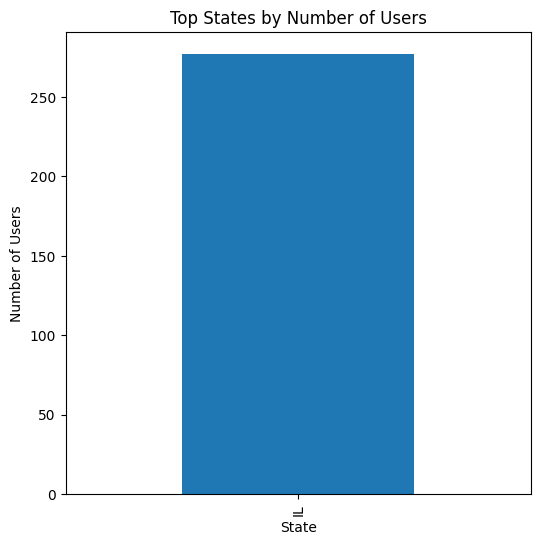

In [15]:
# Top states by number of users
plt.figure(figsize=(6, 6))
test_users['State'].value_counts().head(10).plot(kind='bar')
plt.title("Top States by Number of Users")
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.show()

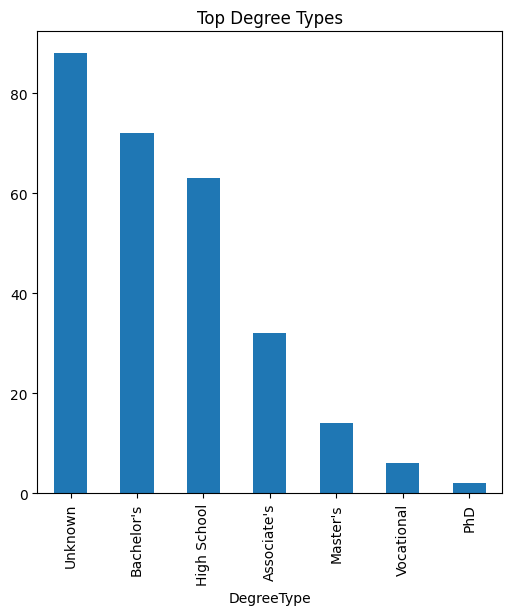

In [16]:
# Top degree types
plt.figure(figsize=(6, 6))
test_users['DegreeType'].value_counts().head(10).plot(kind='bar')
plt.title("Top Degree Types")
plt.show()

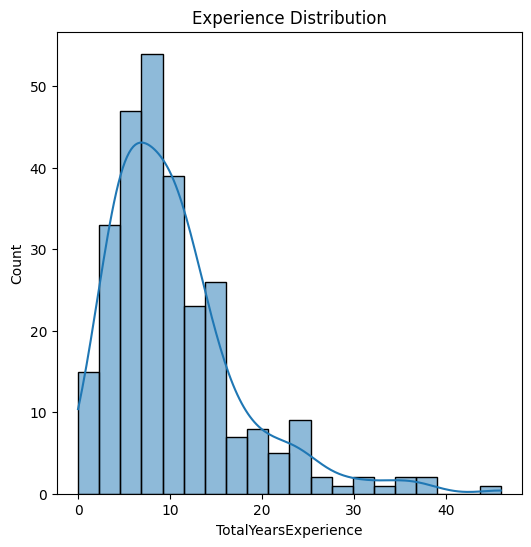

In [17]:
# Experience distribution
plt.figure(figsize=(6, 6))
sns.histplot(test_users['TotalYearsExperience'], bins=20, kde=True)
plt.title("Experience Distribution")
plt.show()

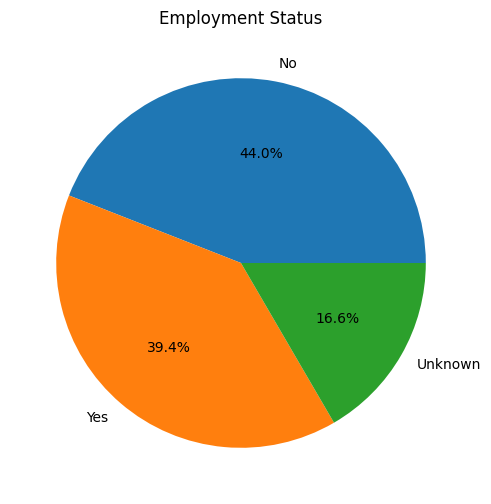

In [18]:
# Employment status
plt.figure(figsize=(6,6))
test_users['CurrentlyEmployed'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Employment Status")
plt.ylabel("")
plt.show()

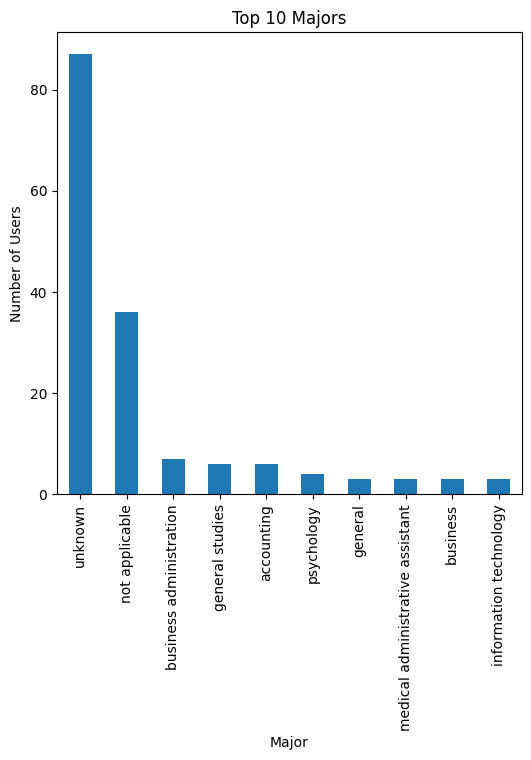

In [19]:
# Top 10 majors
plt.figure(figsize=(6, 6))
test_users['Major'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Majors")
plt.xlabel("Major")
plt.ylabel("Number of Users")
plt.show()

## 5. Save Cleaned Dataset:

In [20]:
test_users.to_csv("../data/clean/test_users_cleaned.csv", index=False)